# Data Augmentation: Geometric Transforms, RandAugment, Mixup, and CutMix

Notebooks 08–11 have progressively closed the accuracy gap on EuroSAT:
- Notebook 08: a plain CNN trained from scratch, ~85–90%.
- Notebook 09: BatchNorm and residuals, making deeper networks trainable.
- Notebook 10: pretrained ResNet18 fine-tuned, ~96–98%.
- Notebook 11: pretrained ViT-B/16, ~97–98%.

The question this notebook asks is: **given a fixed architecture and fixed pretrained weights, how much more can we squeeze out by changing how we feed data to the model?**

The answer in practice is 1–3 percentage points on a mid-sized dataset like EuroSAT, and substantially more on smaller ones. Data augmentation is a *free* source of regularization: instead of changing the model or adding more labeled data, you generate diverse synthetic variations of the training examples you already have.

This notebook covers four augmentation families, in increasing order of sophistication:

1. **Geometric transforms** — random flips and rotations. One-liners in `torchvision.transforms`.
2. **RandAugment** (Cubuk et al., 2019) — random selection over a menu of transforms; the current default in most training recipes.
3. **Mixup** (Zhang et al., 2018) — blend two images and their labels with a random mixing coefficient; smooths decision boundaries.
4. **CutMix** (Yun et al., 2019) — paste a random rectangular crop from one image into another, mixing labels by area.

All four are compared against a no-augmentation baseline on EuroSAT, fine-tuning the same pretrained ResNet18 from notebook 10.

## Learning goals

By the end of this notebook you should be able to explain:

1. the difference between *transform-pipeline* augmentation (applied per sample in the DataLoader) and *batch-level* augmentation (Mixup/CutMix, applied after collation),
2. why augmentation acts as a regularizer and what invariances each technique encodes,
3. how to implement Mixup and CutMix from scratch and wire them into a training loop,
4. what RandAugment is and why it removes the need to hand-tune individual augmentation policies,
5. the empirical tradeoff between augmentation strength and convergence speed on a pretrained model.

In [1]:
import math
import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

seed = 12
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

torch.set_default_dtype(torch.float32)

plt.rcParams.update({
    "figure.figsize": (7.4, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch version:    ", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:             ", device)

PyTorch version:     2.5.1
Torchvision version: 0.20.1
Device:              cuda


## What augmentation does — and why it works

**Augmentation as regularization.** Every time the DataLoader fetches an image, it applies a random transform: a flip, a rotation, a photometric shift. The model sees a slightly different version of each example in every epoch, so it cannot simply memorize the training set. More formally, augmentation injects *invariances* into the training signal: a model that consistently classifies horizontally-flipped satellite images correctly is learning that class identity does not depend on left-right orientation.

**Two stages of augmentation:**

| Stage | Where it happens | Examples |
|-------|-----------------|----------|
| Per-sample, in the DataLoader | `torchvision.transforms` pipeline | flips, rotations, color jitter, RandAugment |
| Per-batch, after collation | custom code in the training loop | Mixup, CutMix |

Mixup and CutMix *require* access to two different examples to blend — you cannot implement them as single-sample transforms. They happen inside the training loop, after the DataLoader has assembled a mini-batch.

**Augmentation interacts with pretraining.** When fine-tuning a pretrained model, the backbone already carries rich invariances learned from ImageNet. The marginal value of augmentation is lower than for from-scratch training, but it still helps — particularly augmentations that act as label-smoothing (Mixup) or that force the model to use the whole image (CutMix).

## EuroSAT data: three transform pipelines, one split

We define three transform pipelines and apply the exact same 80/10/10 split as notebooks 10–11 (`manual_seed(42)`), so any accuracy difference is attributable to augmentation alone. Validation and test sets always use the no-augmentation pipeline.

- `base_transform`: Resize(224) + ToTensor + ImageNet normalize — the no-aug baseline.
- `geom_transform`: adds RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(15).
- `randaug_transform`: adds `RandAugment(num_ops=2, magnitude=9)` on top of geom flips.

Mixup and CutMix are batch-level and use the same `geom_transform` images as input.

`AugDataset` wraps the raw PIL dataset so we can apply different transforms to the same train indices without loading EuroSAT multiple times.

In [2]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Tensors for de-normalizing images in visualization cells
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

base_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

geom_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

randaug_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Load raw dataset (PIL images) — no transform, so we can swap transforms per subset
raw_dataset = torchvision.datasets.EuroSAT(DATA_DIR, download=True, transform=None)
CLASS_NAMES = raw_dataset.classes
n_total = len(raw_dataset)
n_test  = int(0.10 * n_total)
n_val   = int(0.10 * n_total)
n_train = n_total - n_val - n_test

# Replicate the exact split from notebooks 10-11:
# random_split internally calls torch.randperm(n_total, generator=gen)
split_gen = torch.Generator().manual_seed(42)
perm      = torch.randperm(n_total, generator=split_gen).tolist()
train_idx = perm[:n_train]
val_idx   = perm[n_train : n_train + n_val]
test_idx  = perm[n_train + n_val :]


class AugDataset(torch.utils.data.Dataset):
    """Applies a transform at getitem, allowing different transforms on the same indices."""
    def __init__(self, base, indices, transform):
        self.base = base; self.indices = indices; self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]
        return self.transform(img), label


base_train_set    = AugDataset(raw_dataset, train_idx, base_transform)
geom_train_set    = AugDataset(raw_dataset, train_idx, geom_transform)
randaug_train_set = AugDataset(raw_dataset, train_idx, randaug_transform)
val_set  = AugDataset(raw_dataset, val_idx,  base_transform)
test_set = AugDataset(raw_dataset, test_idx, base_transform)

val_loader  = DataLoader(val_set,  batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

print(f"Train / Val / Test: {n_train} / {n_val} / {n_test}")
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

Train / Val / Test: 21600 / 2700 / 2700
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Training harness

Same `evaluate_loader` / `train_model` structure as notebooks 10–11, with one addition: an optional `batch_aug_fn` parameter. When supplied, it takes `(xb, yb)` and returns `(xb_aug, ya, yb2, lam)` — the augmented batch, the two label tensors, and the mixing coefficient. The loss becomes `λ·CE(ŷ, ya) + (1−λ)·CE(ŷ, yb2)`. When `batch_aug_fn=None`, standard cross-entropy is used.

Training accuracy during Mixup/CutMix is computed against `ya` (the primary label) and is therefore a slight underestimate — validation accuracy on clean images is the reliable metric to watch.

In [3]:
def evaluate_loader(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss    += loss_fn(logits, yb).item() * xb.size(0)
            total_correct += (logits.argmax(-1) == yb).sum().item()
            total_n       += xb.size(0)
    return total_loss / total_n, total_correct / total_n


def train_model(
    model_and_optimizer_factory,
    train_loader, val_loader,
    *,
    max_epochs=5, patience=2, min_delta=1e-4,
    model_seed=123, device=device, verbose=True,
    batch_aug_fn=None,
):
    model, optimizer = model_and_optimizer_factory(model_seed)
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best = {"val_loss": float("inf"), "val_acc": None, "epoch": 0, "state_dict": None}
    epochs_no_improve = 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss, running_correct, running_n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if batch_aug_fn is not None:
                xb, ya, yb2, lam = batch_aug_fn(xb, yb)
                logits = model(xb)
                loss = lam * loss_fn(logits, ya) + (1 - lam) * loss_fn(logits, yb2)
                running_correct += (logits.argmax(-1) == ya).sum().item()
            else:
                logits = model(xb)
                loss = loss_fn(logits, yb)
                running_correct += (logits.argmax(-1) == yb).sum().item()
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_n    += xb.size(0)
        train_loss = running_loss / running_n
        train_acc  = running_correct / running_n
        val_loss, val_acc = evaluate_loader(model, val_loader, loss_fn, device)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);  history["val_acc"].append(val_acc)
        if val_loss < best["val_loss"] - min_delta:
            best.update({
                "val_loss": val_loss, "val_acc": val_acc, "epoch": epoch,
                "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            })
            epochs_no_improve = 0
            marker = "*"
        else:
            epochs_no_improve += 1
            marker = " "
        if verbose:
            print(f"epoch {epoch:3d} {marker} | train {train_loss:.3f}/{train_acc:.3f} | val {val_loss:.3f}/{val_acc:.3f}")
        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}")
            break
    if best["state_dict"] is not None:
        model.load_state_dict(best["state_dict"])
    return model, history, best

In [4]:
MAX_EPOCHS = 5
PATIENCE   = 2
BATCH_SIZE = 64

RESNET_WEIGHTS = torchvision.models.ResNet18_Weights.IMAGENET1K_V1

def make_fine_tune_resnet(seed):
    torch.manual_seed(seed)
    model = torchvision.models.resnet18(weights=RESNET_WEIGHTS)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    return model, optimizer

def make_train_loader(dataset):
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                      generator=torch.Generator().manual_seed(2025))

## 1. Baseline: no augmentation

Fine-tune ResNet18 with just `Resize + ToTensor + Normalize` — the same pipeline as notebook 10. This is the floor we want to beat.

In [5]:
print("=== Baseline: no augmentation ===")
base_model, base_hist, base_best = train_model(
    make_fine_tune_resnet, make_train_loader(base_train_set), val_loader,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, model_seed=123,
)
base_test_loss, base_test_acc = evaluate_loader(base_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nBaseline: best val acc {base_best['val_acc']:.4f}, test acc {base_test_acc:.4f}")
base_model.cpu(); torch.cuda.empty_cache()

=== Baseline: no augmentation ===
epoch   1 * | train 0.199/0.938 | val 0.102/0.968
epoch   2 * | train 0.061/0.980 | val 0.086/0.972
epoch   3 * | train 0.033/0.990 | val 0.079/0.975
epoch   4 * | train 0.025/0.992 | val 0.073/0.982
epoch   5 * | train 0.019/0.994 | val 0.066/0.981

Baseline: best val acc 0.9807, test acc 0.9796


## 2. Geometric augmentation

The simplest augmentation family: random horizontal and vertical flips plus a small rotation. These encode the following invariances:

- **Random flip (H/V):** satellite imagery has no canonical orientation — a field looks the same from north or south. Top-down views are genuinely flip-symmetric.
- **Random rotation ±15°:** slight orientation changes do not change the land cover class.

These are almost always beneficial for satellite imagery and cost essentially nothing to implement.

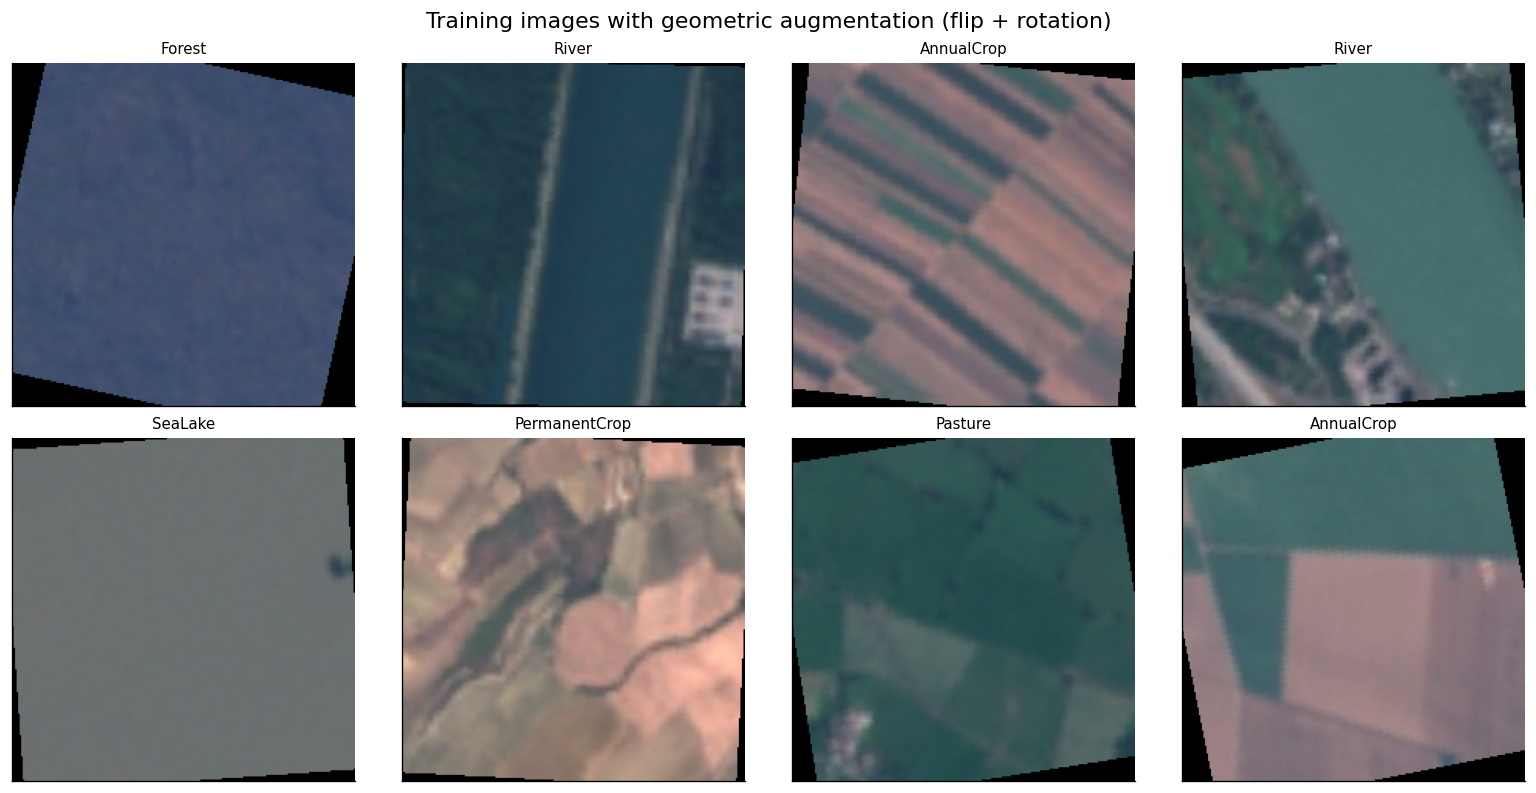

In [6]:
torch.manual_seed(0); np.random.seed(0); random.seed(0)
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), constrained_layout=True)
for col in range(4):
    for row in range(2):
        img_t, label = geom_train_set[col * 300 + row * 100]
        img_np = (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row, col].imshow(img_np)
        axes[row, col].set_title(CLASS_NAMES[label], fontsize=9)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([]); axes[row, col].grid(False)
fig.suptitle("Training images with geometric augmentation (flip + rotation)")
plt.show()

In [7]:
print("=== Geometric augmentation ===")
geom_model, geom_hist, geom_best = train_model(
    make_fine_tune_resnet, make_train_loader(geom_train_set), val_loader,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, model_seed=123,
)
geom_test_loss, geom_test_acc = evaluate_loader(geom_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nGeometric aug: best val acc {geom_best['val_acc']:.4f}, test acc {geom_test_acc:.4f}")
geom_model.cpu(); torch.cuda.empty_cache()

=== Geometric augmentation ===
epoch   1 * | train 0.225/0.928 | val 0.096/0.970
epoch   2 * | train 0.096/0.967 | val 0.075/0.975
epoch   3 * | train 0.077/0.975 | val 0.074/0.973
epoch   4   | train 0.058/0.980 | val 0.083/0.972
epoch   5 * | train 0.058/0.981 | val 0.059/0.980

Geometric aug: best val acc 0.9804, test acc 0.9826


## 3. RandAugment (Cubuk et al., 2019)

Designing augmentation policies by hand is tedious: which transforms, in what order, at what strength? RandAugment answers this with a simple strategy: at each image, **randomly sample `num_ops` transforms from a menu of operations** and apply them at magnitude `magnitude`. Two hyperparameters replace an entire policy search.

The menu includes: **AutoContrast**, **Equalize**, **Rotate**, **Solarize**, **Color**, **Contrast**, **Brightness**, **Sharpness**, **ShearX/Y**, **TranslateX/Y** — photometric, geometric, and color operations.

With `num_ops=2, magnitude=9` (values from the original paper), two of these are drawn uniformly at random each time an image is fetched, giving a different augmentation every epoch.

`torchvision.transforms.RandAugment` works on PIL images and slots directly into a `transforms.Compose` pipeline before `ToTensor`.

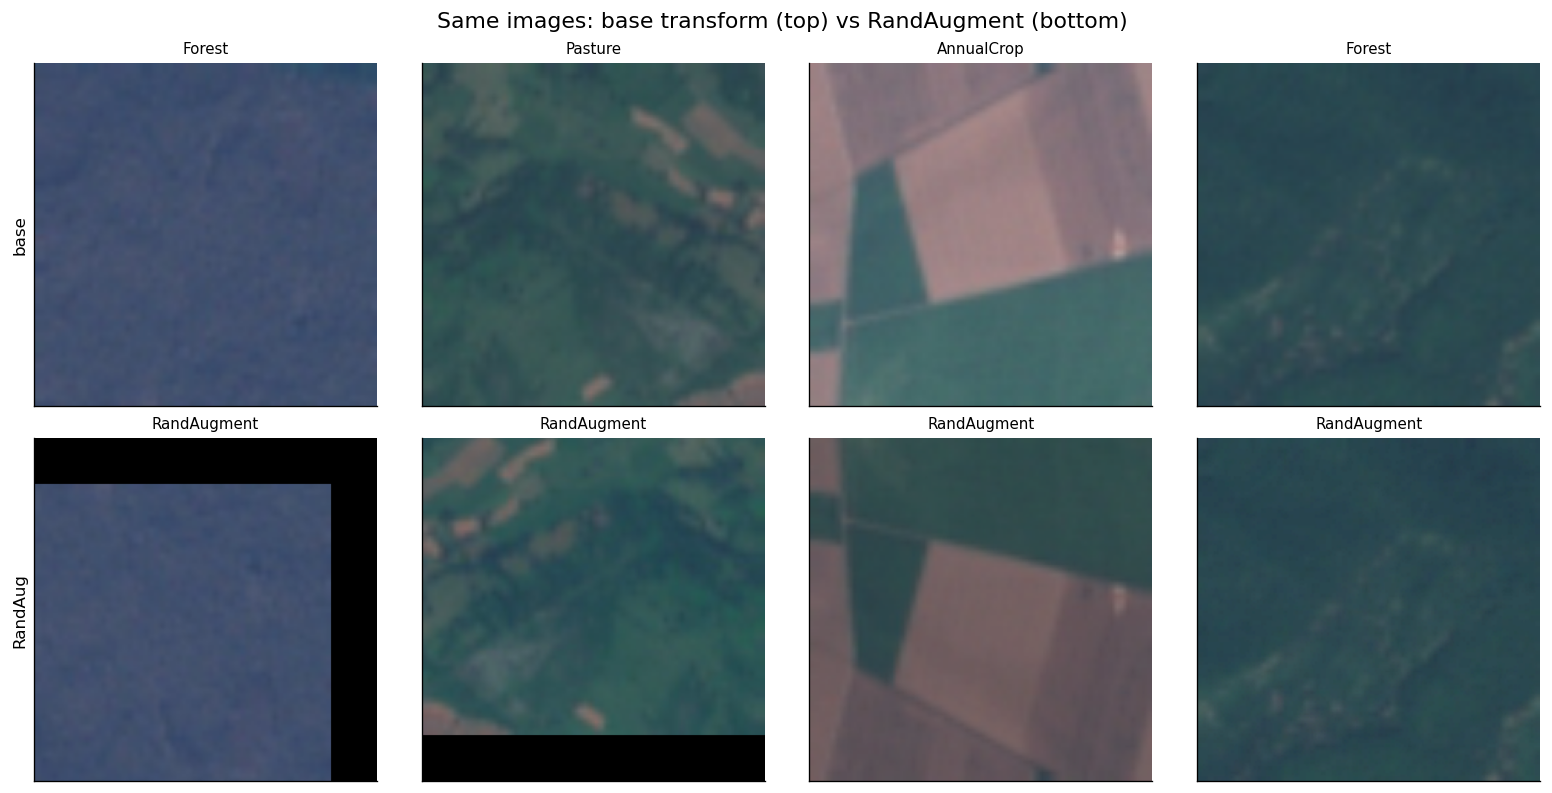

In [8]:
# Same 4 images: base transform (top) vs RandAugment (bottom)
torch.manual_seed(1); np.random.seed(1); random.seed(1)
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), constrained_layout=True)
sample_indices = [train_idx[i * 500] for i in range(4)]
for col, sidx in enumerate(sample_indices):
    raw_img, label = raw_dataset[sidx]
    for row, (tf, row_label) in enumerate([(base_transform, "base"), (randaug_transform, "RandAugment")]):
        img_t  = tf(raw_img)
        img_np = (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row, col].imshow(img_np)
        axes[row, col].set_title(CLASS_NAMES[label] if row == 0 else row_label, fontsize=9)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([]); axes[row, col].grid(False)
axes[0, 0].set_ylabel("base", fontsize=10)
axes[1, 0].set_ylabel("RandAug", fontsize=10)
fig.suptitle("Same images: base transform (top) vs RandAugment (bottom)")
plt.show()

In [9]:
print("=== RandAugment ===")
randaug_model, randaug_hist, randaug_best = train_model(
    make_fine_tune_resnet, make_train_loader(randaug_train_set), val_loader,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, model_seed=123,
)
randaug_test_loss, randaug_test_acc = evaluate_loader(randaug_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nRandAugment: best val acc {randaug_best['val_acc']:.4f}, test acc {randaug_test_acc:.4f}")
randaug_model.cpu(); torch.cuda.empty_cache()

=== RandAugment ===
epoch   1 * | train 0.299/0.904 | val 0.120/0.961
epoch   2 * | train 0.153/0.948 | val 0.070/0.978
epoch   3   | train 0.117/0.962 | val 0.073/0.974
epoch   4 * | train 0.099/0.966 | val 0.064/0.979
epoch   5 * | train 0.090/0.970 | val 0.058/0.982

RandAugment: best val acc 0.9822, test acc 0.9800


## 4. Mixup (Zhang et al., 2018)

Geometric transforms change the *position* of pixels. Mixup changes the *content* of images by blending pairs:

$$\tilde{x} = \lambda x_i + (1 - \lambda) x_j, \qquad \tilde{y} = \lambda y_i + (1 - \lambda) y_j$$

where $\lambda \sim \text{Beta}(\alpha, \alpha)$. The network learns to produce an output that is a linear interpolation between two class distributions — a form of *label smoothing* that penalizes overconfident predictions.

**Implementation details:**
- Sample one $\lambda$ per mini-batch (common practice; each image in the batch is blended with a different shuffled partner but they all share the same $\lambda$).
- Loss: $\lambda \cdot \text{CE}(\hat{y}, y_a) + (1-\lambda) \cdot \text{CE}(\hat{y}, y_b)$.
- $\alpha = 0.4$ is a standard choice for image classification. Higher $\alpha$ produces mixes with $\lambda$ closer to 0.5.

**Intuition:** Mixup forces the model to learn that a 60%/40% mixture of a Forest and an AnnualCrop image should produce logits that are 60% Forest, 40% AnnualCrop. This discourages sharp decision boundaries and produces better-calibrated probabilities.

Mixup is a **batch-level** operation, so it lives outside the `DataLoader` transform pipeline. We pass it to `train_model` as `batch_aug_fn`.

In [10]:
class Mixup:
    def __init__(self, alpha=0.4):
        self.alpha = alpha

    def __call__(self, xb, yb):
        lam = float(np.random.beta(self.alpha, self.alpha))
        idx = torch.randperm(xb.size(0), device=xb.device)
        return lam * xb + (1 - lam) * xb[idx], yb, yb[idx], lam

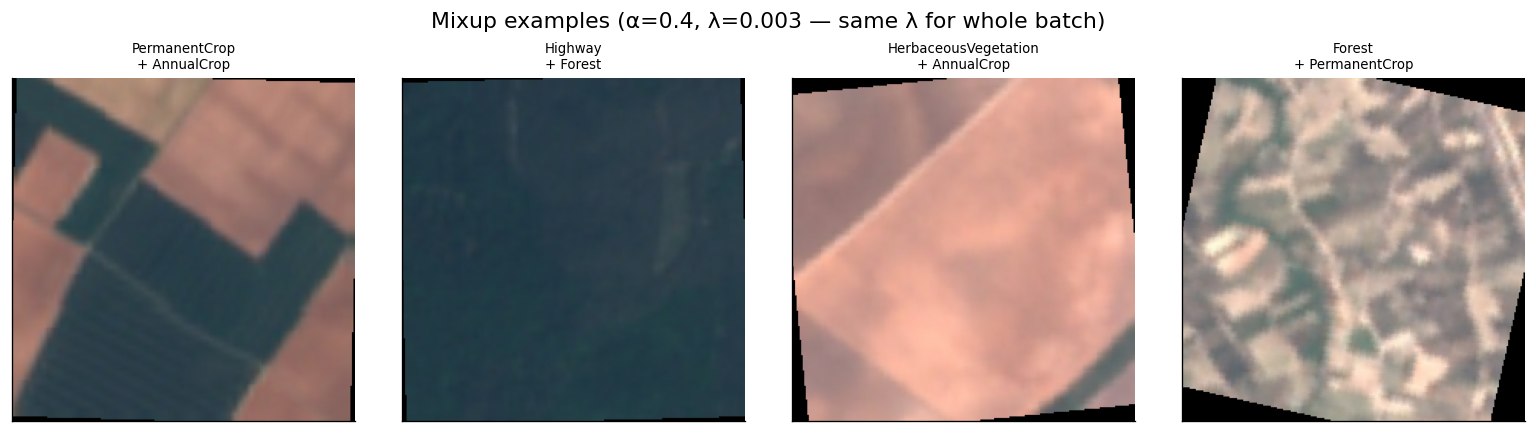

In [11]:
torch.manual_seed(7); np.random.seed(7)
_tmp = DataLoader(geom_train_set, batch_size=8, shuffle=True,
                  generator=torch.Generator().manual_seed(7))
xb_orig, yb_orig = next(iter(_tmp))
xb_mix, ya_mix, yb_mix2, lam_mix = Mixup(alpha=0.4)(xb_orig, yb_orig)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), constrained_layout=True)
for i, ax in enumerate(axes.flat):
    img = (xb_mix[i] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(
        f"{CLASS_NAMES[ya_mix[i].item()]}\n+ {CLASS_NAMES[yb_mix2[i].item()]}",
        fontsize=8,
    )
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"Mixup examples (\u03b1=0.4, \u03bb={lam_mix:.3f} — same \u03bb for whole batch)")
plt.show()

In [12]:
print("=== Mixup (on geometric-augmented images) ===")
mixup_model, mixup_hist, mixup_best = train_model(
    make_fine_tune_resnet, make_train_loader(geom_train_set), val_loader,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, model_seed=123,
    batch_aug_fn=Mixup(alpha=0.4),
)
mixup_test_loss, mixup_test_acc = evaluate_loader(mixup_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nMixup: best val acc {mixup_best['val_acc']:.4f}, test acc {mixup_test_acc:.4f}")
mixup_model.cpu(); torch.cuda.empty_cache()

=== Mixup (on geometric-augmented images) ===
epoch   1 * | train 0.818/0.497 | val 0.308/0.953
epoch   2 * | train 0.665/0.503 | val 0.172/0.975
epoch   3 * | train 0.638/0.563 | val 0.121/0.978
epoch   4   | train 0.659/0.568 | val 0.150/0.976
epoch   5   | train 0.578/0.532 | val 0.156/0.979
Early stopping at epoch 5

Mixup: best val acc 0.9778, test acc 0.9770


## 5. CutMix (Yun et al., 2019)

CutMix is a spatial variant of Mixup: instead of blending pixel values globally, it **cuts a rectangular region** from one image and **pastes** it into another. Labels are mixed proportionally to the pasted area:

$$\tilde{x} = \mathbf{M} \odot x_i + (1 - \mathbf{M}) \odot x_j, \qquad \lambda = 1 - \frac{|B|}{WH}$$

where $\mathbf{M}$ is a binary mask defined by box $B$, and $\lambda$ is determined by the actual clipped box area.

**CutMix vs Mixup:**
- Mixup produces *blurry* composites where every pixel is a weighted average. CutMix produces *crisp* images where each region is 100% one image.
- CutMix forces the model to recognize class-relevant features from *partial* views, acting as a spatial dropout on discriminative regions.
- In the original paper, CutMix outperformed Mixup on ImageNet; results vary by dataset.

**Implementation:** sample $\lambda$ from $\text{Beta}(\alpha, \alpha)$ to determine the cut area ratio, pick a random center, compute the box dimensions, then adjust $\lambda$ after clipping to image boundaries.

In [13]:
class CutMix:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def __call__(self, xb, yb):
        lam = float(np.random.beta(self.alpha, self.alpha))
        idx = torch.randperm(xb.size(0), device=xb.device)
        H, W = xb.shape[-2], xb.shape[-1]
        cut_h = int(H * math.sqrt(1 - lam))
        cut_w = int(W * math.sqrt(1 - lam))
        cy, cx = np.random.randint(H), np.random.randint(W)
        y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
        x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
        xb_mix = xb.clone()
        xb_mix[:, :, y1:y2, x1:x2] = xb[idx, :, y1:y2, x1:x2]
        lam = 1.0 - (y2 - y1) * (x2 - x1) / (H * W)
        return xb_mix, yb, yb[idx], lam

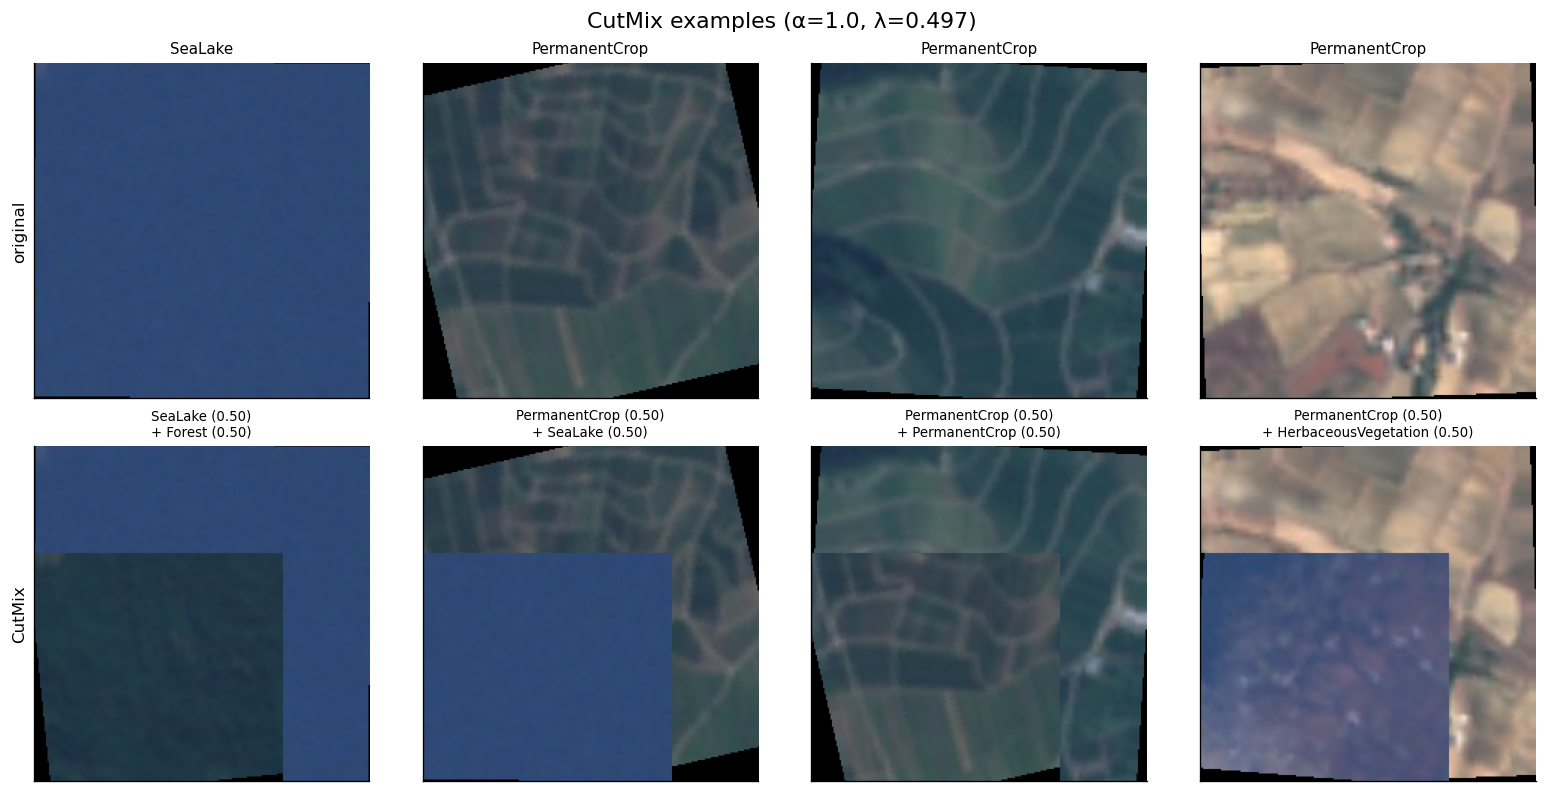

In [14]:
torch.manual_seed(9); np.random.seed(9)
_tmp2 = DataLoader(geom_train_set, batch_size=8, shuffle=True,
                   generator=torch.Generator().manual_seed(9))
xb_orig2, yb_orig2 = next(iter(_tmp2))
xb_cut, ya_cut, yb_cut2, lam_cut = CutMix(alpha=1.0)(xb_orig2, yb_orig2)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), constrained_layout=True)
for i in range(4):
    img_orig = (xb_orig2[i] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    img_cm   = (xb_cut[i]   * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img_orig)
    axes[0, i].set_title(CLASS_NAMES[ya_cut[i].item()], fontsize=9)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([]); axes[0, i].grid(False)
    axes[1, i].imshow(img_cm)
    axes[1, i].set_title(
        f"{CLASS_NAMES[ya_cut[i].item()]} ({lam_cut:.2f})\n"
        f"+ {CLASS_NAMES[yb_cut2[i].item()]} ({1-lam_cut:.2f})",
        fontsize=8,
    )
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([]); axes[1, i].grid(False)
axes[0, 0].set_ylabel("original", fontsize=10)
axes[1, 0].set_ylabel("CutMix", fontsize=10)
fig.suptitle(f"CutMix examples (\u03b1=1.0, \u03bb={lam_cut:.3f})")
plt.show()

In [15]:
print("=== CutMix (on geometric-augmented images) ===")
cutmix_model, cutmix_hist, cutmix_best = train_model(
    make_fine_tune_resnet, make_train_loader(geom_train_set), val_loader,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, model_seed=123,
    batch_aug_fn=CutMix(alpha=1.0),
)
cutmix_test_loss, cutmix_test_acc = evaluate_loader(cutmix_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nCutMix: best val acc {cutmix_best['val_acc']:.4f}, test acc {cutmix_test_acc:.4f}")
cutmix_model.cpu(); torch.cuda.empty_cache()

=== CutMix (on geometric-augmented images) ===
epoch   1 * | train 0.992/0.703 | val 0.201/0.970
epoch   2 * | train 0.809/0.746 | val 0.152/0.974
epoch   3 * | train 0.746/0.770 | val 0.139/0.979
epoch   4   | train 0.709/0.778 | val 0.153/0.977
epoch   5 * | train 0.706/0.754 | val 0.125/0.985

CutMix: best val acc 0.9848, test acc 0.9830


## 6. Combined: Mixup + CutMix

Modern training recipes (e.g., the `timm` library, PyTorch's `torchvision.transforms.v2`) typically apply **either** Mixup or CutMix at random for each batch — roughly 50/50. The two augmentations are complementary: Mixup blends globally, CutMix cuts locally. Alternating between them gives broader coverage of the augmentation space.

`torchvision.transforms.v2.MixUp` and `transforms.v2.CutMix` provide built-in implementations (torchvision ≥ 0.15). The `MixupOrCutMix` wrapper below shows how straightforward the composition is.

In [16]:
class MixupOrCutMix:
    """Randomly applies Mixup or CutMix with equal probability each batch."""
    def __init__(self, mixup_alpha=0.4, cutmix_alpha=1.0):
        self._mixup  = Mixup(alpha=mixup_alpha)
        self._cutmix = CutMix(alpha=cutmix_alpha)

    def __call__(self, xb, yb):
        if np.random.rand() < 0.5:
            return self._mixup(xb, yb)
        return self._cutmix(xb, yb)

In [17]:
print("=== Mixup + CutMix combined (on geometric-augmented images) ===")
combined_model, combined_hist, combined_best = train_model(
    make_fine_tune_resnet, make_train_loader(geom_train_set), val_loader,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, model_seed=123,
    batch_aug_fn=MixupOrCutMix(mixup_alpha=0.4, cutmix_alpha=1.0),
)
combined_test_loss, combined_test_acc = evaluate_loader(combined_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nMixup+CutMix: best val acc {combined_best['val_acc']:.4f}, test acc {combined_test_acc:.4f}")
combined_model.cpu(); torch.cuda.empty_cache()

=== Mixup + CutMix combined (on geometric-augmented images) ===
epoch   1 * | train 0.959/0.569 | val 0.219/0.964
epoch   2 * | train 0.802/0.668 | val 0.148/0.975
epoch   3   | train 0.751/0.640 | val 0.209/0.974
epoch   4   | train 0.713/0.647 | val 0.182/0.977
Early stopping at epoch 4

Mixup+CutMix: best val acc 0.9752, test acc 0.9774


## Head-to-head comparison

Six runs, same ResNet18 pretrained weights, same split. The only variable is the augmentation strategy applied during training.

In [18]:
runs = [
    ("baseline (no aug)",    base_best,     base_test_acc),
    ("geometric",            geom_best,     geom_test_acc),
    ("RandAugment",          randaug_best,  randaug_test_acc),
    ("Mixup (geom+)",        mixup_best,    mixup_test_acc),
    ("CutMix (geom+)",       cutmix_best,   cutmix_test_acc),
    ("Mixup+CutMix (geom+)", combined_best, combined_test_acc),
]
header = f"{'augmentation':>24s}   {'best val acc':>12s}   {'test acc':>8s}   {'best epoch':>10s}"
print(header); print("-" * len(header))
for name, b, t_acc in runs:
    print(f"{name:>24s}   {b['val_acc']:12.4f}   {t_acc:8.4f}   {b['epoch']:10d}")

            augmentation   best val acc   test acc   best epoch
---------------------------------------------------------------
       baseline (no aug)         0.9807     0.9796            5
               geometric         0.9804     0.9826            5
             RandAugment         0.9822     0.9800            5
           Mixup (geom+)         0.9778     0.9770            3
          CutMix (geom+)         0.9848     0.9830            5
    Mixup+CutMix (geom+)         0.9752     0.9774            2


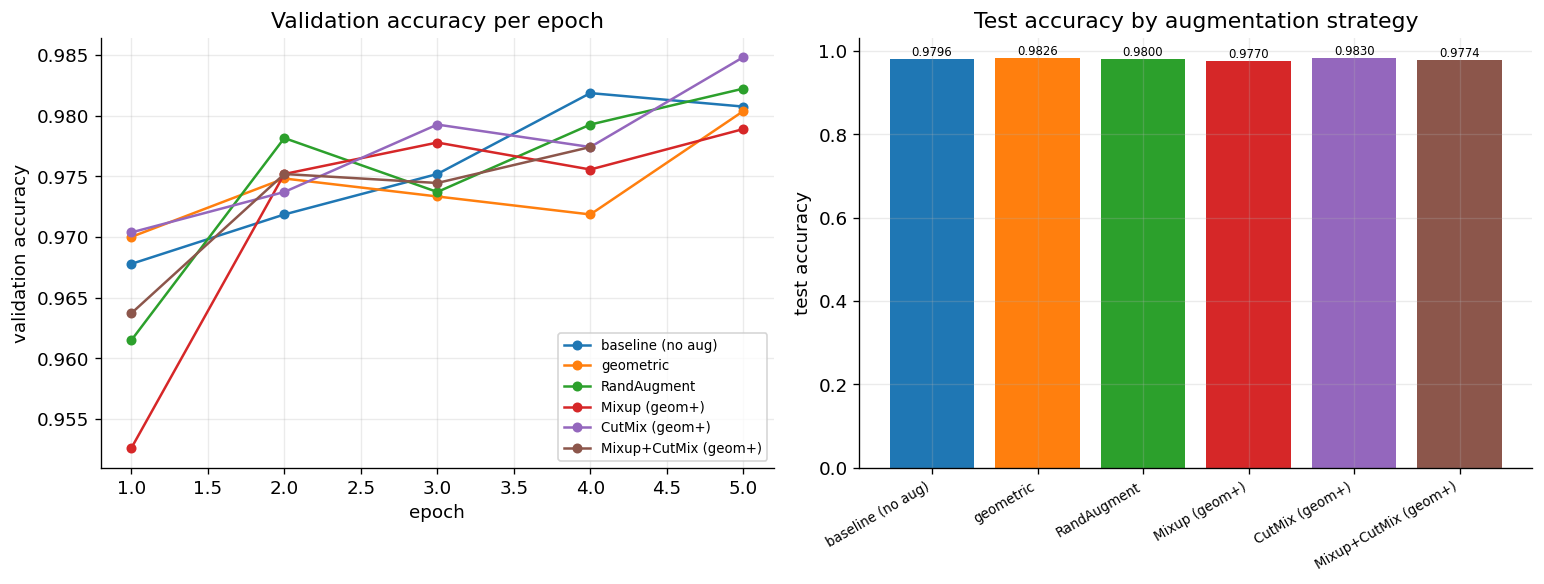

In [19]:
run_labels = [r[0] for r in runs]
run_hists  = [base_hist, geom_hist, randaug_hist, mixup_hist, cutmix_hist, combined_hist]
run_taccs  = [r[2] for r in runs]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

for name, hist in zip(run_labels, run_hists):
    axes[0].plot(hist["epoch"], hist["val_acc"], marker="o", label=name, markersize=5)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation accuracy")
axes[0].set_title("Validation accuracy per epoch")
axes[0].legend(loc="lower right", fontsize=8)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
x = range(len(run_labels))
bars = axes[1].bar(x, run_taccs, color=colors[:len(run_labels)])
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(run_labels, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("test accuracy")
axes[1].set_title("Test accuracy by augmentation strategy")
for bar, acc in zip(bars, run_taccs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f"{acc:.4f}", ha="center", va="bottom", fontsize=7)

fig.tight_layout()
plt.show()

## Summary

| Augmentation strategy    | Stage | Key mechanism | EuroSAT typical gain |
|--------------------------|-------|---------------|----------------------|
| Geometric (flip+rotate)  | per sample | spatial invariance | +0–1% |
| RandAugment              | per sample | broad transform menu | +0–1% |
| Mixup                    | per batch  | label smoothing, boundary regularization | +0–2% |
| CutMix                   | per batch  | spatial mixing, attention regularization | +0–2% |
| Mixup+CutMix             | per batch  | complementary coverage | similar or better than either |

Key takeaways:

1. **With strong pretraining, augmentation gains are modest.** A pretrained ResNet18 on EuroSAT is already in the high 90s; there is not much headroom. The same augmentations produce larger gains from scratch or on small datasets.
2. **Geometric flips and rotations are almost always free.** Satellite imagery has no canonical orientation, so top-down flips are valid invariances. These should be in every EuroSAT pipeline.
3. **Mixup and CutMix trade convergence speed for regularization.** Training accuracy measured against `ya` appears lower because labels are mixed. The validation curve often converges more slowly but to a better minimum.
4. **RandAugment magnitude matters.** High magnitudes can be harmful on satellite images whose spectral statistics differ from natural photos. Tuning `magnitude` is worthwhile.
5. **The best modern recipe stacks them.** Flip + RandAugment per sample, then random Mixup-or-CutMix per batch. This is what libraries like `timm` and `torchvision.transforms.v2` make easy.

Reasonable next directions:

- **Notebook 13 — Self-attention from scratch.** Build the multi-head attention block from first principles on a 1-D task. Sets up the NLP / LLM direction.
- **Notebook 14 — Self-supervised pretraining.** What if labeled ImageNet weights are not available? Contrastive learning (SimCLR) or masked-image modeling (MAE).
- **Augmentation + smaller datasets.** Create a 10% EuroSAT subset (~2,160 training images). The Mixup/CutMix gap will be substantially wider.

## Exercises

1. **Magnitude sweep.** Train with `RandAugment(num_ops=2, magnitude=M)` for M ∈ {3, 6, 9, 15}. At what magnitude does accuracy peak, and when does it start hurting?

2. **Mixup alpha sweep.** Try Mixup with α ∈ {0.1, 0.2, 0.4, 0.8, 2.0}. Higher α produces mixes closer to λ=0.5; lower α produces mixes that are mostly one image. Plot val accuracy vs α.

3. **Per-sample lambda.** The `Mixup` class above uses one λ per batch. Modify it to sample one λ per image pair (a different λ for each element of the batch). Does this change the accuracy or training dynamics?

4. **Small-data regime.** Create a training set with only 10% of the training data (~2,160 samples) using `AugDataset(raw_dataset, train_idx[:2160], geom_transform)`. Compare baseline vs Mixup+CutMix. How much larger is the augmentation benefit?

5. **Label smoothing as a simpler alternative.** PyTorch's `nn.CrossEntropyLoss(label_smoothing=0.1)` provides a softer supervision signal similar to Mixup, without modifying the data pipeline. Modify `train_model` to accept a `label_smoothing` parameter and compare it to Mixup on the baseline transform. Which works better? Which is cheaper to implement?

6. **Attention maps under CutMix.** Take the CutMix-trained ResNet18 and the baseline ResNet18. Use `torch.nn.functional.conv2d` with global average pooling to build a simple Class Activation Map (CAM) for a few test images. Does the CutMix-trained model attend to more distributed regions of the image, as the theory predicts?